
# RIDGE VS LASSO REGULARIZATION

### Import the necessary libraries and modules

In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import mglearn
import numpy.random as npr
from IPython.display import HTML
from IPython.display import display
import matplotlib.pyplot as plt

# Regressors
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Preprocessing and pipeline
from sklearn.impute import SimpleImputer

# Train test split and cross validation
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    PolynomialFeatures
)
from sklearn.feature_extraction.text import CountVectorizer

### Motivation for Regularization

Let's create a toy dataset with 20 points

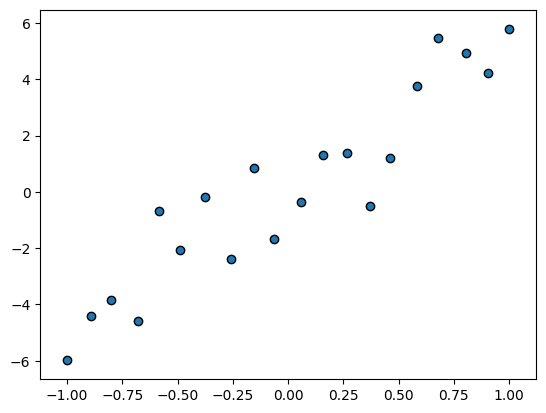

In [ ]:
np.random.seed(4)
N = 20
X = np.linspace(-1, 1, N) + npr.randn(N) * 0.01
X = X[:, None]
y = npr.randn(N, 1) + X * 5

mglearn.discrete_scatter(X, y, s=6, labels=["training data"]);


Now let's try fitting a polynomial of degree 19 to this data. For this, we try polynomial feature engineering

1.0

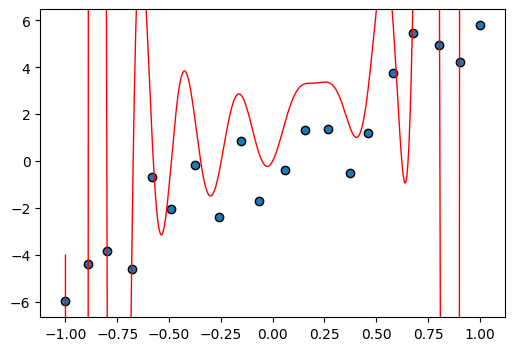

In [ ]:
pf = PolynomialFeatures(19)
Z = pf.fit_transform(X)

lr = LinearRegression()
lr.fit(Z, y)
w_lr_19 = lr.coef_.flatten()
grid = np.linspace(min(X), max(X), 1000)
grid_poly_19 = pf.fit_transform(grid)
plt.figure(figsize=(6,4))
mglearn.discrete_scatter(X, y, s=6, labels=["training data"])
plt.plot(grid, grid_poly_19 @ w_lr_19, c="red", linewidth=1);
lr.score(Z, y)

The results show significant overfitting. This implies that the model is more complex than needed. Bigger values of weights indicate that the model is very sensitive to the training data.

In [ ]:
pd.DataFrame(w_lr_19, index=pf.get_feature_names_out(), columns=["weights"]).tail()

,weights
x0^15,-5.150150e+07
x0^16,-5.316861e+06
x0^17,3.466582e+07
x0^18,1.482311e+06
x0^19,-9.517721e+06


In [ ]:
print(max(abs(w_lr_19)))

51501499.263656385


It is evident form the extremely large magnitudes of the weights that the model is very unstable - this means that a slight change in feature value will result in an extreme change in the target value.

### Solution 1: Use a lower degree polynomial


0.8717193637247818

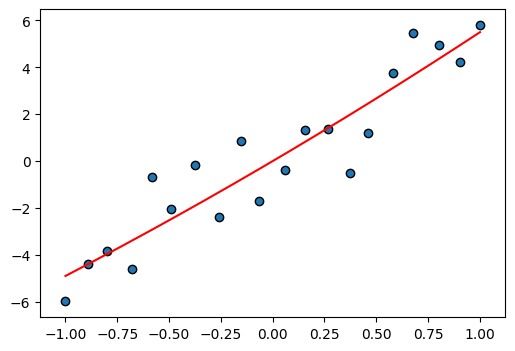

In [ ]:
pf = PolynomialFeatures(2)
Z = pf.fit_transform(X)
lr = LinearRegression()
lr.fit(Z, y)
w_lr_2 = lr.coef_.flatten()
grid_poly_2 = pf.fit_transform(grid)
plt.figure(figsize=(6,4))
mglearn.discrete_scatter(X, y, s=6, labels=["training data"])
plt.plot(grid, grid_poly_2 @ w_lr_2, c="red");
lr.score(Z, y)

Using a lower degree polynomial fits the data better. However, if the true relationship really was complicated, then if we restricted the degree of the polynomial, we'd miss out on it.

### Solution 2: Use Regularization

The idea of regularization is to "regularize" weights so that they are small and less sensitive to the data. `Ridge` is the regularized version of `LinearRegression`

#### Ridge Regularization

Ridge regression is a type of linear regression that includes a regularization term to prevent overfitting. It works by adding a penalty to the size of the coefficients in the linear equation, which discourages the model from fitting the noise in the data too closely. This penalty is controlled by a parameter, often called lambda or alpha, which determines how strongly the coefficients are shrunk towards zero. By balancing the fit of the model and the complexity of the coefficients, ridge regression helps improve the model's generalization to new, unseen data.

0.9135817441429814

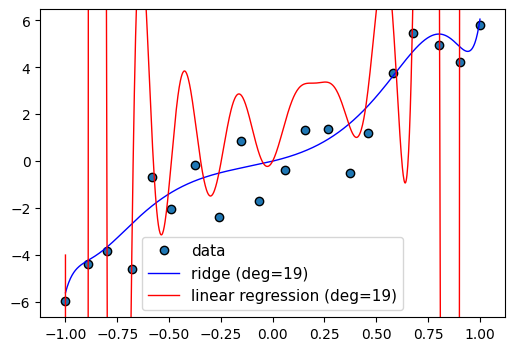

In [ ]:
pf = PolynomialFeatures(19)
Z = pf.fit_transform(X)

r = Ridge(alpha=0.01)  # Regularized linear regression
r.fit(Z, y)
w_ridge_19 = r.coef_.flatten()
plt.figure(figsize=(6,4))
mglearn.discrete_scatter(X, y, s=6, labels=["training data"])
grid_poly_ridge = pf.fit_transform(grid)
plt.plot(grid, grid_poly_ridge @ w_ridge_19, c="blue", linewidth=1);
plt.plot(grid, grid_poly_19 @ w_lr_19, c="red", linewidth=1);
plt.legend(["data", 'ridge (deg=19)', 'linear regression (deg=19)'], loc="best", fontsize=11);
r.score(Z, y)

In [ ]:
pd.DataFrame(w_ridge_19, index=pf.get_feature_names_out(), columns=["weights"]).tail()

,weights
x0^15,0.780600
x0^16,1.170325
x0^17,2.655623
x0^18,1.800171
x0^19,4.240822


In [ ]:
print(max(abs(w_ridge_19)))

8.010363113222326


After regularization, even though we used a degree $N-1$ polynomial, we didn't end up with an overfitted model. Here, we are keeping all the complex features but assigning smaller weights to a higher degree polynomial. Similarly, we can add regularization to many models, not just least squares with a polynomial basis.


#### But why are smaller weights better?

- Somewhat non-intuitive.
- Suppose $x_1$ and $x_2$ are nearby each other, we might expect that they have similar $\hat{y}$.
- If we change feature1 value by a small amount $\epsilon$ in $x_2$, leaving everything else the same, we might think that the prediction would be the same. But if we have bigger weights small change in $x_2$ has a large effect on the prediction.
- In linear models, the rate of change of the prediction function is proportional to the individual weights. So if we want the function to change slowly, we want to ensure that the weights stay small.
- The idea is to avoid putting all our energy into one feature, which might give us over-confident predictions and lead to overfitting.

#### Overview of L1 and L2 norms

Given a vector $w$,

- L1 norm $\lVert w \rVert_1 = \lvert w_1 \rvert + \lvert w_2 \rvert + \dots + \lvert w_n \rvert$
- L2 norm $\lVert w \rVert_2 = (w_1^2 + w_2^2 + \dots + w_n^2)^{1/2}$
- Square of the L2 norm $\lVert w \rVert_2^2 = (w_1^2 + w_2^2 + \dots + w_n^2)$

In [ ]:
from numpy.linalg import norm

w = np.array([0, -2, 4])

l1 = norm(w, 1)  # sum of absolute values
l2 = norm(w, 2)  # square root of sum of the squared values
print("The l1 norm of %s is: %0.3f" % (w, l1))
print("The l2 norm of %s is: %0.3f" % (w, l2))

The l0 norm of [ 0 -2  4] is: 2.000
The l1 norm of [ 0 -2  4] is: 6.000
The l2 norm of [ 0 -2  4] is: 4.472


### Least squares Notation

It's the square of the L2 norm of the difference between predicted y's and true y's.  

$$ f(w) = \sum_{i=1}^{n}{(w^Tx_i - y_i)^2}$$

$$ f(w) = \lVert{Xw -y}\rVert_2^2$$

### Regularization intuition

Another popular method to control model complexity is by adding a penalty on the complexity of the model
* Instead of minimizing just the Loss, we will minimize Loss + λ
* Loss term measures how well the model fits the data.
* Model complexity term, which is also referred to as **regularization term**, measures model complexity.
* A scalar λ decides the overall impact of the regularization term.


### How to quantify model complexity?

Total number of features with non-zero weights
* L0 regularization: quantify model complexity as $ \lVert w \rVert \ $, L0 norm of $w$.

As a function of weights: A feature weight with high absolute value is more complex than the feature weight with low absolute value.
* L2 regularization: quantify model complexity as $\lVert w \rVert_2^2$, square of the L2 norm of $w$.
* L1 regularization: quantify model complexity as $\lVert w \rVert_1$, L1 norm of $w$.

## `Ridge`: L2 Regularization of Linear Regression

Assuming red and green models have the same training error and if you are forced to choose one of them, which one would you pick?
* **Pick the solid green line because its slope is smaller.**
* Small change in $x_i$ has a smaller change in prediction $y_i$
* Since $w$ is less sensitive to the training data, it's likely to generalize better.  

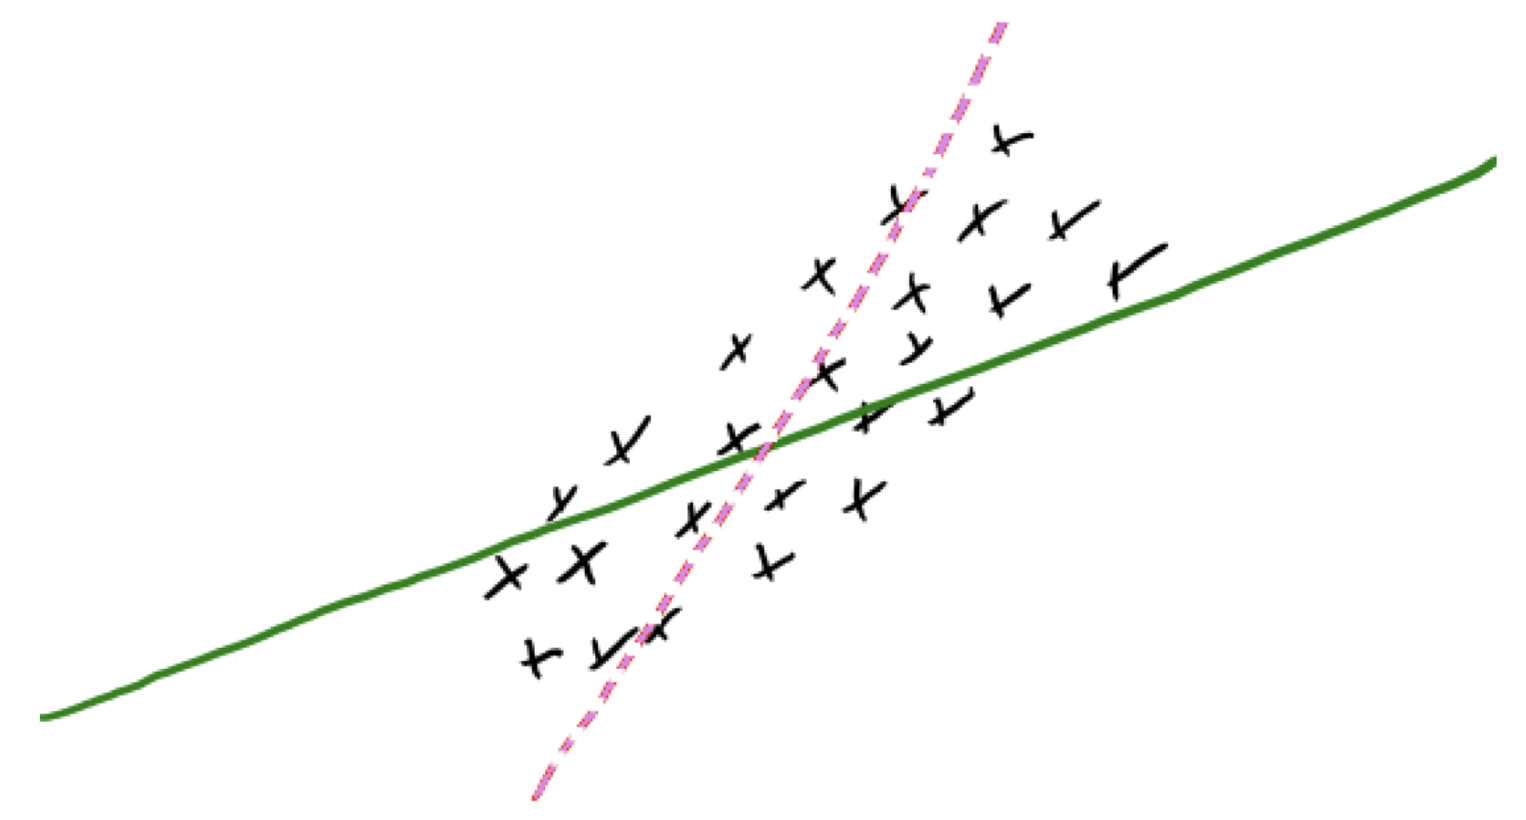

**Standard regularization strategy is L2 regularization**
* We incorporate L2 penalty in the loss function $f(w)$:
$$f(w) = \sum_i^n(w^Tx_i - y_i)^2 + \lambda\sum_j^d w_j^2 \text{ or }$$
$$f(w) = \lVert Xw - y\rVert_2^2 + \lambda \lVert w\rVert_2^2$$

- $\lVert Xw - y\rVert_2^2 \rightarrow$ square of the $L2$ norm of $Xw -y$
- $\lambda \rightarrow$ regularization strength    
- $\lVert w\rVert_2^2 \rightarrow$  square of the L2 norm of $w$      
    - sum of the squared weight values.
- Objective balances getting low error vs. having small slopes $w_j$
- In terms of fundamental trade-off:
    - You can increase the training error.
    - Nearly-always reduces overfitting and the validation error.  
    
- In `sklearn` the linear regression estimator with L2 regulaization is called `Ridge`
- `Ridge` has a hyperparameter `alpha` that represents the regularization strength
- We get least squares with $\lambda = 0$.
- As we increase $\alpha$
    - $\lVert Xw - y\rVert_2^2$ goes $\uparrow$
    - $\lVert w\rVert_2^2$  goes $\downarrow$
    - Though individual $w_j$ can increase or decrease with lambda because we use the L2-norm, the large ones decrease the most.
    
- As `alpha` goes up, we increase the regularization strength.
- The weights become smaller and smaller but tend not to become exactly zero.             

### Code Demo for `Ridge`

We'll be using the inbuilt california housing dataset along with ridge regularization to fit and train a polynomial regressor model.

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
X = housing["data"]
y = housing["target"]

pf = PolynomialFeatures(degree=2, include_bias=False)
X = pf.fit_transform(X)
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X, y, random_state=0)

ss = StandardScaler()
X_train = ss.fit_transform(X_train_poly)
X_test = ss.transform(X_test_poly)


In [ ]:
def lr_loss_squared(w, X, y): # define OLS loss function
    return np.sum((y - X @ w) ** 2)

In [ ]:
alphas = [0, 0.01, 0.1, 1.0, 10, 100, 1000, 1000000]
weight_shrinkage_data = {'alpha':[], '||Xw - y||^2':[], '||w||^2':[], 'intercept':[], 'train score':[], 'test score':[]}

for (i, alpha) in enumerate(alphas):
    r = Ridge(alpha=alpha)
    r.fit(X_train, y_train)
    weight_shrinkage_data['alpha'].append(alpha)
    OLS = np.round(lr_loss_squared(r.coef_, X_train, y_train), 4)
    l2_term = np.round(norm(r.coef_, 2)**2, 4)
    intercept = np.round(r.intercept_,4)
    weight_shrinkage_data['||Xw - y||^2'].append(OLS)
    weight_shrinkage_data['||w||^2'].append(l2_term)
    weight_shrinkage_data['intercept'].append(intercept)
    weight_shrinkage_data['train score'].append(np.round(r.score(X_train, y_train), 2))
    weight_shrinkage_data['test score'].append(np.round(r.score(X_test, y_test), 2))

In [ ]:
pd.DataFrame(weight_shrinkage_data)

,alpha,||Xw - y||^2,||w||^2,intercept,train score,test score
0,0.00,73099.4882,7634.4579,2.0744,0.69,-0.73
1,0.01,73113.1963,4239.9359,2.0744,0.69,-0.17
2,0.10,73222.8589,888.3987,2.0744,0.68,0.62
3,1.00,73437.3112,77.0152,2.0744,0.67,0.02
4,10.00,73597.9629,8.4983,2.0744,0.66,-3.80
5,100.00,73777.7373,2.5195,2.0744,0.65,-3.37
6,1000.00,74363.2804,0.7118,2.0744,0.62,0.10
7,1000000.00,85565.9420,0.0008,2.0744,0.08,0.08


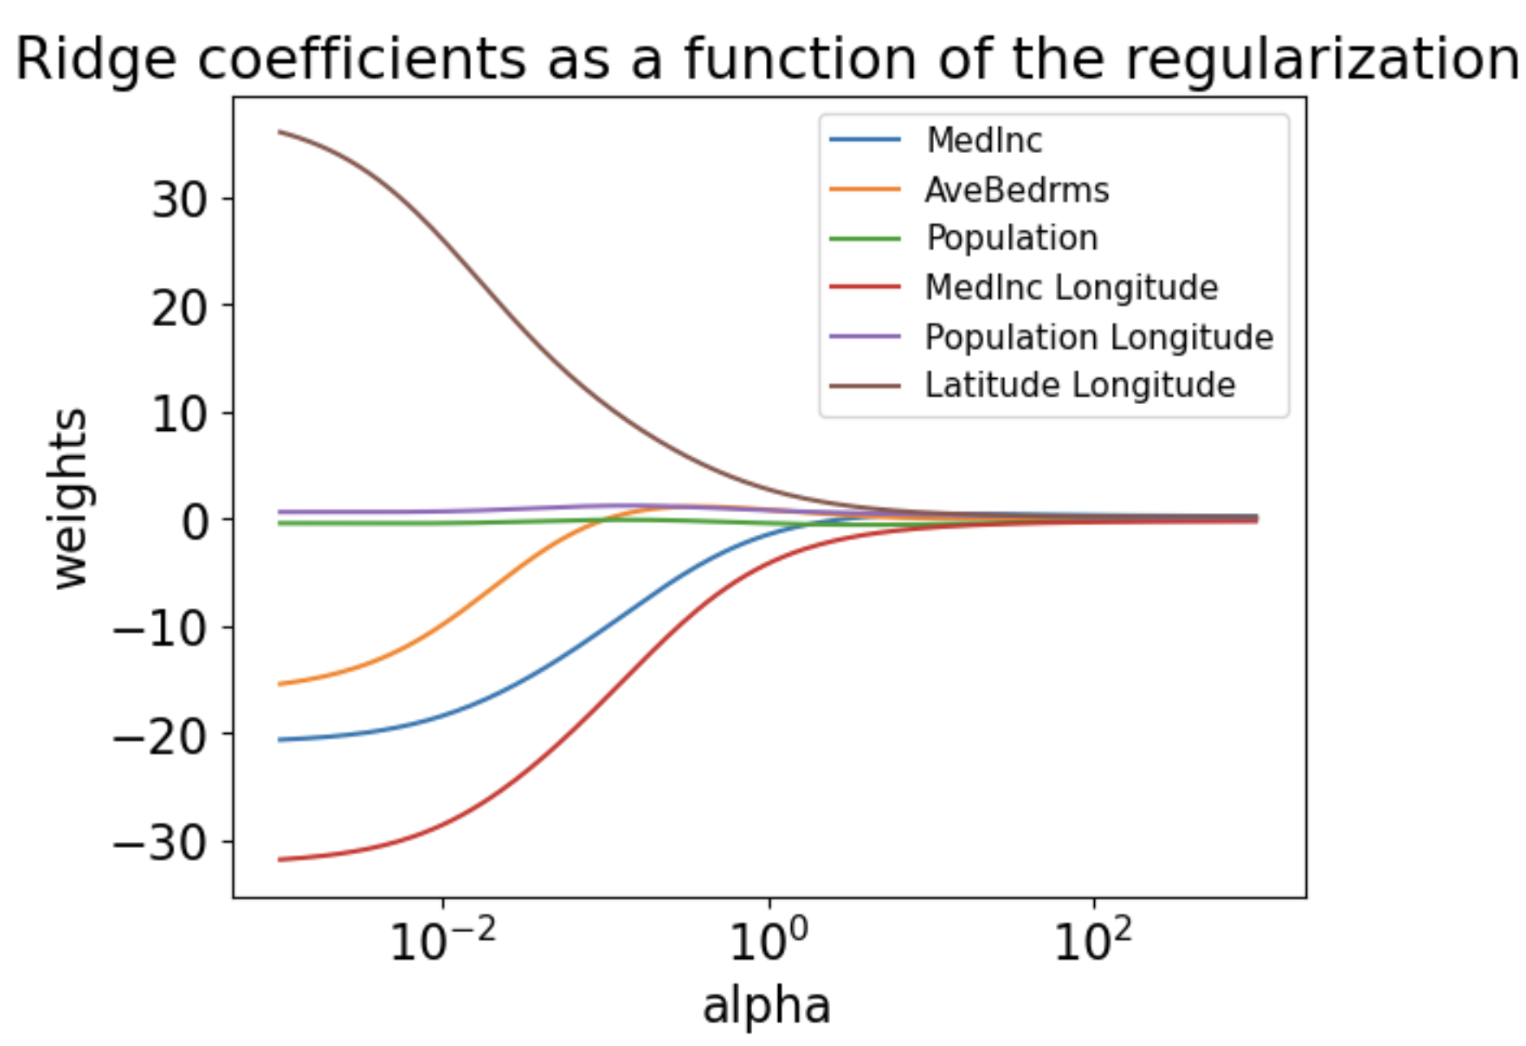

Now let's look at individual feature importances

In [ ]:
feature_names = pf.get_feature_names_out()

In [ ]:
r10 = Ridge(alpha=0.10)
r10.fit(X_train, y_train)
coefs = (
    pd.DataFrame(r10.coef_, feature_names, columns=["coef"])
    .query("coef != 0")
    .sort_values("coef")
    .reset_index()
    .rename(columns={"index": "variable"})
)
coefs

,variable,coef
0,MedInc Longitude,-16.762873
1,MedInc,-10.178537
2,HouseAge Longitude,-9.608717
3,HouseAge,-6.986869
4,MedInc Latitude,-5.683734
5,HouseAge Latitude,-2.931366
6,AveBedrms Longitude,-2.152434
7,AveBedrms Latitude,-1.934514
8,Longitude,-1.637599
9,AveRooms AveBedrms,-1.571689


#### How to pick $\lambda$ or `alpha` of `Ridge`?

- Theory: as $n$ grows $\lambda$ should be in the range $O(1)$ to $\sqrt{n}$.
- Practice: optimize validation set or cross-validation error.
    - Almost always decreases the test error.

#### Some properties of L2-regularization

1. Solution $w$ is unique. It has to do with the smoothness of the function.
2. **Almost always improves the validation error.**
3. No collinearity issues.
4. Less sensitive to changes in $X$.
5. Gradient descent (optimization algorithm) converges faster
6. Worst case: just set $\lambda$ small and get the same performance

## `Lasso`: L1 Regularization of Linear Regression


- An alternative to `Ridge` (L2-regularization for least squares) is `Lasso`.
- Instead of L0-norm or L2-norm, regularize with L1-norm.

$$f(w) = \sum_i^n(w^TX_i - y_i)^2 + \lambda\sum_j^d \lvert w_j \lvert\text{ or }$$
$$f(w) = \lVert Xw - y\rVert_2^2 + \lambda \lVert w\rVert_1$$


- $\lambda \rightarrow$ regularization strength
- $\lVert w\rVert_1 \rightarrow$  L1-norm of $w$  
- Objective balances getting low error vs. having small values for $w_j$

#### Similarities with L2-regularization

- L1-regularization
$$f(w) = \lVert Xw - y\rVert_2^2 + \lambda \lVert w\rVert_1$$

- L2-regularization
$$f(w) = \lVert Xw - y\rVert_2^2 + \lambda \lVert w\rVert_2^2$$

- Both shrink weights.
- Both result in lower validation error.


### L1-regularization characteristics

- The consequence of using L1-norm is that some features are exactly zero, which means that the features are entirely ignored by the model.
- This can be considered as a form of feature selection!!
- L1-regularization simultaneously regularizes and selects features.
- Very fast alternative to search and score methods



Let's apply `Lasso` on the California housing data.

In [ ]:
X_train.shape

(15480, 44)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used:", np.sum(lasso.coef_ != 0))

Training set score: 0.00
Test set score: -0.00
Number of features used: 0


- We observe that it's not using any features - like a dummy model. It's underfitting.
- Similar to `Ridge` it also has a regularization hyperparameter `alpha`.
- Let's decrease it to reduce underfitting.
- Let's examine weight shrinkage for L1 regularization
- Lasso loss is not a smooth function.
- Slower compared to Ridge.

In [ ]:
from numpy.linalg import norm
alphas = [0, 0.0001, 0.01, 0.1, 1]
weight_shrinkage_data = {'alpha':[], '||Xw - y||^2':[], '||w||_1':[], 'intercept':[], 'train score':[], 'test score':[]}

for (i, alpha) in enumerate(alphas):
    print('alpha: ', alpha)
    l = Lasso(alpha=alpha, max_iter=10000)
    l.fit(X_train, y_train)
    weight_shrinkage_data['alpha'].append(alpha)
    OLS = np.round(lr_loss_squared(l.coef_, X_train, y_train), 4)
    l1_term = np.round(norm(r.coef_, 1), 4)
    intercept = np.round(l.intercept_, 4)
    weight_shrinkage_data['||Xw - y||^2'].append(OLS)
    weight_shrinkage_data['||w||_1'].append(l1_term)
    weight_shrinkage_data['intercept'].append(intercept)
    weight_shrinkage_data['train score'].append(np.round(l.score(X_train, y_train), 2))
    weight_shrinkage_data['test score'].append(np.round(l.score(X_test, y_test), 2))

alpha:  0


<ipython-input-20-1d3626f94e5d>:8: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  l.fit(X_train, y_train)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.394e+03, tolerance: 2.066e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


alpha:  0.0001


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.778e+03, tolerance: 2.066e+00
  model = cd_fast.enet_coordinate_descent(


alpha:  0.01
alpha:  0.1
alpha:  1


In [ ]:
pd.DataFrame(weight_shrinkage_data)

,alpha,||Xw - y||^2,||w||_1,intercept,train score,test score
0,0.0000,73398.6742,0.1125,2.0744,0.67,0.52
1,0.0001,73462.0080,0.1125,2.0744,0.67,0.20
2,0.0100,74463.3147,0.1125,2.0744,0.62,0.33
3,0.1000,76723.2012,0.1125,2.0744,0.51,0.48
4,1.0000,87271.1329,0.1125,2.0744,0.00,-0.00


Now let's see what's the difference between `Ridge` and `Lasso`

In [ ]:
r = Ridge(alpha = 0.1).fit(X_train, y_train)
print("Training set score: {:.2f}".format(r.score(X_train, y_train)))
print("Test set score: {:.2f}".format(r.score(X_test, y_test)))
print("Number of features used:", np.sum(r.coef_ != 0))

Training set score: 0.68
Test set score: 0.62
Number of features used: 44


In [ ]:
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used:", np.sum(lasso.coef_ != 0))

Training set score: 0.51
Test set score: 0.48
Number of features used: 3


- In this case we are not really getting better results with Lasso.
- In fact, Lasso is not able to do better than linear regression.
- Often you might see better scores than `Ridge` with fewer features.  
- If `alpha` is too low, we reduce the effect of overfitting and the results are similar to linear regression.

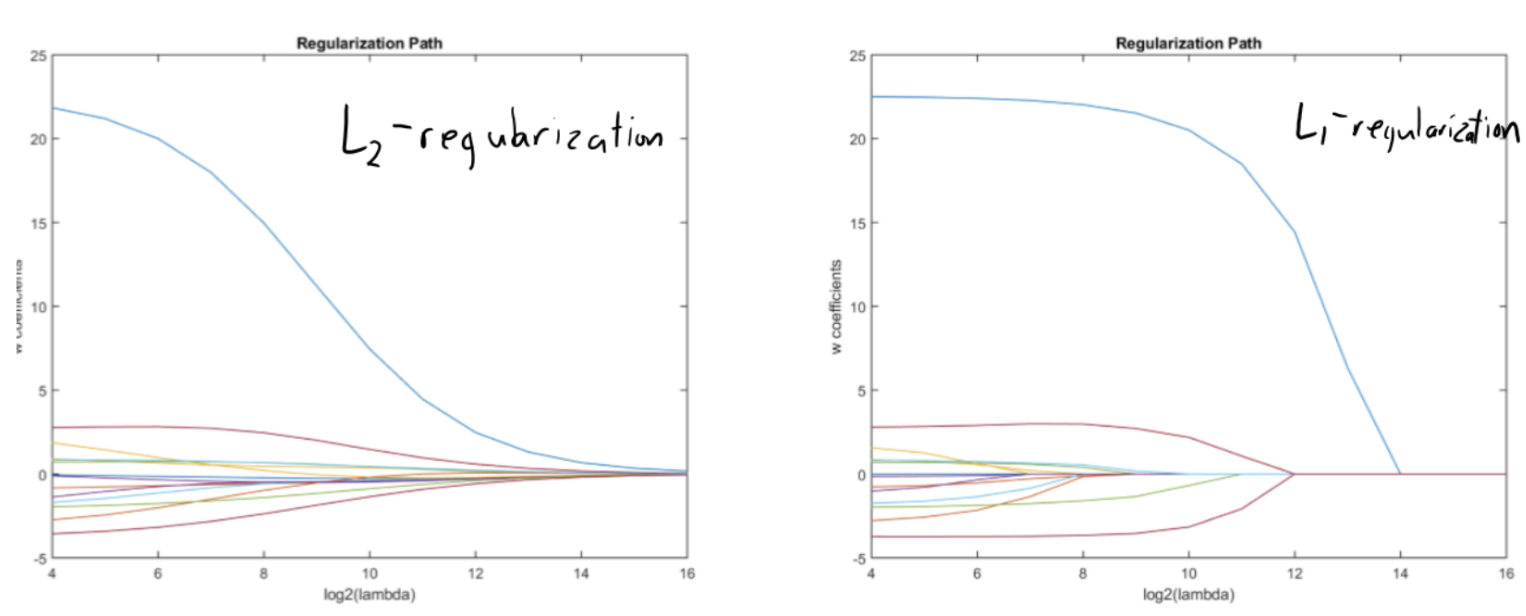

#### Some properties of L1 regularization

1. Almost always improves the validation error.
2. Can learn with exponential number of irrelevant features.
3. Less sensitive to changes in $X$.
4. The solution is not unique.
5. L1 regularization is an effective way of feature selection.